In [10]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy.stats import multivariate_normal
from matplotlib.animation import FuncAnimation
from matplotlib.patches import Ellipse
import matplotlib.transforms as transforms

np.random.seed(42)

# ── Data generation ────────────────────────────────────────────────────────────
mean1 = [4.5, 1.8];  cov1 = [[0.2, 0.05],  [0.05, 0.1]]
mean2 = [6.0, 2.5];  cov2 = [[0.3, -0.04], [-0.04, 0.2]]
data1 = np.random.multivariate_normal(mean1, cov1, 100)
data2 = np.random.multivariate_normal(mean2, cov2, 100)
X = np.vstack((data1, data2))

k = 2
n, d = X.shape

In [11]:
# ── Initialisation ─────────────────────────────────────────────────────────────
means       = X[np.random.choice(n, k, replace=False)].copy()
covariances = [np.cov(X.T) for _ in range(k)]
weights     = np.ones(k) / k

# ── Helpers ────────────────────────────────────────────────────────────────────
COLORS = ['#e63946', '#457b9d']   # red / steel-blue

def confidence_ellipse(mean, cov, ax, n_std=2.0, **kwargs):
    """Draw a covariance ellipse at n_std standard deviations."""
    vals, vecs = np.linalg.eigh(cov)
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]
    angle = np.degrees(np.arctan2(*vecs[:, 0][::-1]))
    width, height = 2 * n_std * np.sqrt(vals)
    ell = Ellipse(xy=mean, width=width, height=height, angle=angle, **kwargs)
    ax.add_patch(ell)
    return ell

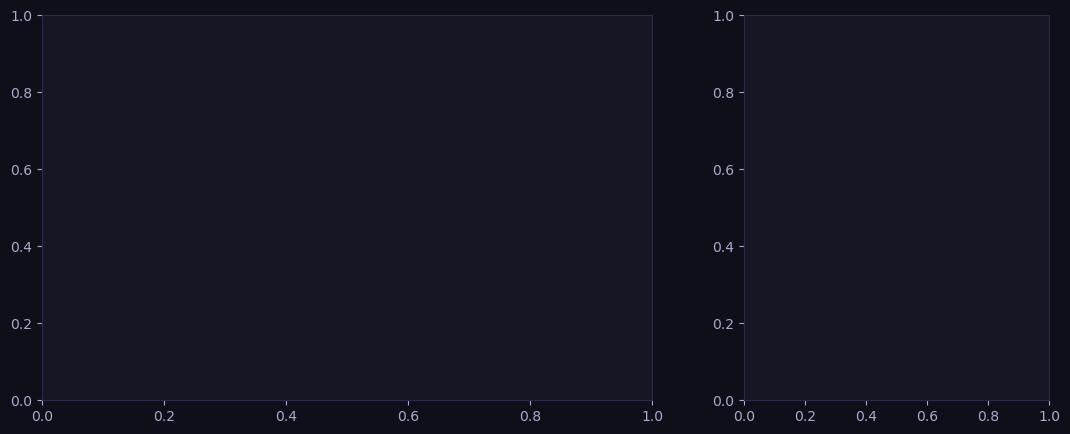

In [12]:
# ── Helpers ────────────────────────────────────────────────────────────────────
COLORS = ['#e63946', '#457b9d']   # red / steel-blue

def confidence_ellipse(mean, cov, ax, n_std=2.0, **kwargs):
    """Draw a covariance ellipse at n_std standard deviations."""
    vals, vecs = np.linalg.eigh(cov)
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]
    angle = np.degrees(np.arctan2(*vecs[:, 0][::-1]))
    width, height = 2 * n_std * np.sqrt(vals)
    ell = Ellipse(xy=mean, width=width, height=height, angle=angle, **kwargs)
    ax.add_patch(ell)
    return ell

# ── Figure setup ───────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5),
                         gridspec_kw={'width_ratios': [2, 1]})
fig.patch.set_facecolor('#0f0f1a')
for ax in axes:
    ax.set_facecolor('#161625')
    ax.tick_params(colors='#aaaacc')
    for spine in ax.spines.values():
        spine.set_edgecolor('#2a2a4a')

ax_main, ax_info = axes

In [13]:
# Scatter
scatter = ax_main.scatter(X[:, 0], X[:, 1], c=np.zeros(n),
                          cmap='RdYlBu', vmin=0, vmax=1,
                          s=30, alpha=0.85, linewidths=0)

# Cluster-mean markers (one per component)
mean_scatters = [
    ax_main.scatter([], [], c=COLORS[i], marker='*',
                    s=350, zorder=5, edgecolors='white', linewidths=0.8)
    for i in range(k)
]

# Covariance ellipses (placeholders)
ellipses = []
for i in range(k):
    e = confidence_ellipse(means[i], covariances[i], ax_main, n_std=2,
                           edgecolor=COLORS[i], facecolor='none',
                           linestyle='--', linewidth=1.5, alpha=0.6)
    ellipses.append(e)

ax_main.set_xlabel('x₁', color='#aaaacc')
ax_main.set_ylabel('x₂', color='#aaaacc')
title = ax_main.set_title('EM  ·  Iteration 0', color='white',
                           fontsize=13, fontweight='bold')

cbar = fig.colorbar(scatter, ax=ax_main, pad=0.02)
cbar.set_label('Responsibility  (component 0)', color='#aaaacc')
cbar.ax.yaxis.set_tick_params(color='#aaaacc')
plt.setp(cbar.ax.yaxis.get_ticklabels(), color='#aaaacc')

[None, None, None, None, None, None]

In [14]:
# ── Info panel ─────────────────────────────────────────────────────────────────
ax_info.axis('off')
info_text = ax_info.text(0.05, 0.95, '', transform=ax_info.transAxes,
                          va='top', color='white', fontsize=9,
                          fontfamily='monospace',
                          bbox=dict(boxstyle='round,pad=0.6',
                                    facecolor='#1e1e30', edgecolor='#3a3a5a'))

log_likes = []
ax_ll = None   # lazily created after first point

iterations = 40

In [15]:
# ── EM update ──────────────────────────────────────────────────────────────────
def update(frame):
    global means, covariances, weights

    # ── E-step ──────────────────────────────────────────────────────────────
    responsibilities = np.zeros((n, k))
    for i in range(k):
        rv = multivariate_normal(means[i], covariances[i], allow_singular=True)
        responsibilities[:, i] = weights[i] * rv.pdf(X)

    resp_sum = responsibilities.sum(axis=1, keepdims=True)
    resp_sum[resp_sum == 0] = 1e-300
    responsibilities /= resp_sum

    # Log-likelihood
    ll = np.log(resp_sum + 1e-300).sum()
    log_likes.append(ll)

    # ── M-step ──────────────────────────────────────────────────────────────
    Nk = responsibilities.sum(axis=0)
    weights = Nk / n
    means[:] = np.dot(responsibilities.T, X) / Nk[:, np.newaxis]

    new_covs = []
    for i in range(k):
        diff = X - means[i]
        cov = np.dot(responsibilities[:, i] * diff.T, diff) / Nk[i]
        cov += 1e-6 * np.eye(d)
        new_covs.append(cov)
    covariances = new_covs

    # ── Update main scatter ──────────────────────────────────────────────────
    scatter.set_array(responsibilities[:, 0])   # colour = responsibility of comp 0

    for i in range(k):
        mean_scatters[i].set_offsets(means[i:i+1])

    # Redraw ellipses (remove old, add new)
    for e in ellipses:
        e.remove()
    for i in range(k):
        ellipses[i] = confidence_ellipse(
            means[i], covariances[i], ax_main, n_std=2,
            edgecolor=COLORS[i], facecolor=COLORS[i],
            linestyle='--', linewidth=1.5, alpha=0.15)

    title.set_text(f'EM  ·  Iteration {frame + 1} / {iterations}')

    # ── Info panel text ──────────────────────────────────────────────────────
    lines = ['  MIXTURE MODEL  \n']
    for i in range(k):
        lines.append(f'Component {i}  (π={weights[i]:.3f})')
        lines.append(f'  μ = [{means[i,0]:.3f}, {means[i,1]:.3f}]')
        lines.append(f'  σ² = [{covariances[i][0,0]:.3f}, {covariances[i][1,1]:.3f}]')
        lines.append('')
    lines.append(f'Log-likelihood\n  {ll:.2f}')
    info_text.set_text('\n'.join(lines))

    return [scatter, title, info_text] + mean_scatters + ellipses


ani = FuncAnimation(fig, update, frames=iterations, interval=500, blit=False)

plt.suptitle('Gaussian Mixture Model — Expectation-Maximisation',
             color='white', fontsize=14, y=1.01)
plt.tight_layout()

<Figure size 640x480 with 0 Axes>

In [16]:
ani = FuncAnimation(fig, update, frames=iterations, interval=500, blit=False)

plt.suptitle('Gaussian Mixture Model — Expectation-Maximisation',
             color='white', fontsize=14, y=1.01)
plt.tight_layout()

from IPython.display import HTML
plt.rcParams["animation.html"] = "jshtml"

ani = FuncAnimation(fig, update, frames=iterations, interval=500, blit=False)

plt.suptitle(
    'Gaussian Mixture Model — Expectation-Maximisation',
    fontsize=14,
    y=1.02
)

plt.tight_layout()

ani


c:\Users\Harshith\miniconda3\envs\agentic\lib\site-packages\matplotlib\animation.py:908: UserWarning: Animation was deleted without rendering anything. This is most likely not intended. To prevent deletion, assign the Animation to a variable, e.g. `anim`, that exists until you output the Animation using `plt.show()` or `anim.save()`.
  warnings.warn(


<Figure size 640x480 with 0 Axes>